# CRE 3 - Assignment 3 : PFTR Model for Ethylene Oxide Hydrolysis

Group 6: 

 Ivanna Garzon 3104602

 Franziska Jehle 1136767
 
 Saif...

Reaction Conditions:
    
Onuorah, Gunorubon: Continuous  Stirred  Tank Reactor for the Non-Catalytic hydrolysis of Ethylene Oxide to Mono Ethylene Glycol (MEG)
                    T = 200 °C, p = 14-22 atm

Design and Analysis: L_R/D_R = 2, 467, 461, 455 kPa, 150 °C
https://doi.org/10.1016/j.cep.2019.107744

DOI 10.31031/PPS.2024.06.000637: 212 °C, 35 bar


assumptions: no backmixing, no side reactions, no consecutive reactions

Process Intensification: reactive distillation

## 1. Introduction and Motivation

....

## 2. PFTR Model

### 2.1 Balance Equations

In the following an ideal plug flow tubular reactor (PFTR) is assumed with steady state behavior. This means there is no backmixing in axial direction and there is ideal mixing in radial direction. This results in no gradients in radial flow direction but gradients in axial flow direction due to chemical reaction. Thus all fluid elements leaving the reactor have the same residence time.

The mass balance for the PFTR can be in general written as:

\begin{align*}
    \frac{dc_i}{d\tau}=\sum_{j}\nu_{i,j}r_j
\end{align*}

$c_i$ is the concentration of component, j the reaction, $\nu_{i,j}$ the stoichiometric factor of component i in reaction j.

This results in the following mass balance equations for the considered reaction:

\begin{align*}
    \frac{dc_{EO}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{H_2O}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{G}}{d\tau}=r
\end{align*}

The residence time $\tau$ can also be expressed with the following equation:

\begin{align*}
    \tau = \frac{z}{u}
\end{align*}

For a constant fluid velocity $u$ this results in:

\begin{align*}
    d\tau = \frac{dz}{u}
\end{align*}

This and rearranging the equations leads to following expressions for the reaction rate:

\begin{align*}
    r=-u\frac{dc_{EO}}{dz}
\end{align*}

\begin{align*}
    r=-u\frac{dc_{H_2O}}{dz}
\end{align*}

\begin{align*}
    r=u\frac{dc_{EG}}{dz}
\end{align*}

Since a first order reaction kinetics is assumed, the reaction rate can be expressed as follows:

\begin{align*}
    r_{EO}=-\frac{dc_{EO}}{d\tau}=c_{EO} \cdot k(T)=c_{EO} \cdot k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)
\end{align*}

The temperature dependent kinetic constant $k(T)$ can be expressed as:

\begin{equation*}
k(T)=k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)\;\mathrm{s^{-1}}
\end{equation*}

The heat balance can be written as: 

\begin{align*}
    \rho c_p \frac{dT}{d\tau}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

For a constant fluid velocity through the reactor, $u$, the heat balance can also be written as:

\begin{align*}
    \rho c_p u \frac{dT}{dz}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

The boundary conditions can be expressed as follows:

\begin{align*}
    c_i(z=0)=c_{i,e}
\end{align*}

\begin{align*}
    T_i(z=0)=T_e
\end{align*}

### 2.2. Import Libraries

At first the libraries are imported, which are further used in the code.

In [122]:
import sys
import numpy as np
import scipy
from scipy.integrate import solve_ivp
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

### 2.3 Parameters

At first the parameters for the base case are implemented for further use in the equations.

In [123]:
# ==========================================
# PARAMETERS
# ==========================================

R = 8.314  # ideal gas constant / J/mol*K

# Kinetics
k0 = 5.01E6 # pre-exponential factor / 1/s
EA = 72500  # #activation energy / J/mol

# Process conditions
u = 1.0      # fluid velocity / m/s
Tin = 423    # inlet temperature / K

# Concentrations
cEO0 = 2.27 * 1000  # inlet concentration of EO / mol/m3
cEG0 = 0.0           # inlet concentration of EG / mol/m3

# Thermodynamics
dHr = -92.2e3         # reaction enthalpy / J/mol

rho = 1000           # density / kg/m^3
cp = 4.19e3          # heat capacity / J/kg*K

# Reactor geometry
dR = 0.03            # tube diameter / m
L = 300              # reactor length / m

# Heat transfer
hwall = 0.5e3        # wall heat transfer coefficient / W/m^2*K
Twall = 423          # wall temperature / K

z = np.linspace(0, L, 300)

### 2.4 Geometric relations

The cross diameter of the tubular reactor can be calculated as follows:

\begin{align*}
    A=\frac{\pi}{4}d_R^2
\end{align*}

The circumference can be calculated as follows:

\begin{align*}
    C=\pi \cdot d_R
\end{align*}

In [124]:
A_cross = np.pi * dR**2 / 4
A_wall_per_length = np.pi * dR

### 2.5. Kinetic Model and PFTR Balance Equations

In the following the equations for the kinetic expressions as well as the heat and mass balance equations are implemented. 

In [125]:
def kinetics(T, cEO):
    # Arrhenius equation
    k = k0 * np.exp(-EA/(R*T)) #rate constant / 1/s
    
    # First-order reaction rate
    r = k * cEO
    
    return r

In [126]:
def PFTR(z, y):
    'Function for component balance and energy balance'
    # y is a vector containing concentrations of components c_EO (f[0]) and c_EG (f[1]) and temperature T of the reaction mixture (f[2])
    cEO = y[0]
    cEG = y[1]
    T   = y[2]

    # reaction rate from kinetics function
    r = kinetics(T, cEO)

    # differential equations
    dcEOdz = -r/u #change in EO concentration along the reactor length / mol/m^3/m
    dcEGdz = r/u #change in EG concentration along the reactor length / mol/m^3/m

    # Energy balance
    heat_generation = (-dHr) * r #heat generated by the reaction / W/m^3
    heat_transfer = hwall * A_wall_per_length * (T - Twall) #heat transferred to the wall / W/m

    dTdz = (heat_generation*A_cross - heat_transfer) / (rho*cp*u*A_cross) #change in temperature along the reactor length / K/m

    return [dcEOdz, dcEGdz, dTdz]

# vector of initial conditions
y0 = np.array([cEO0, cEG0, Tin]) #initial concentrations and temperature


The system of ODEs is solved numerically using scipy's solve_ivp.

In [127]:
zeval = np.linspace(0, L, 300) #points at which to evaluate the solution

sol = solve_ivp(
    PFTR,
    [0, L], #span of the reactor length
    y0,
    method='BDF',
    t_eval=zeval
)


The results are summarized for the plotting. 

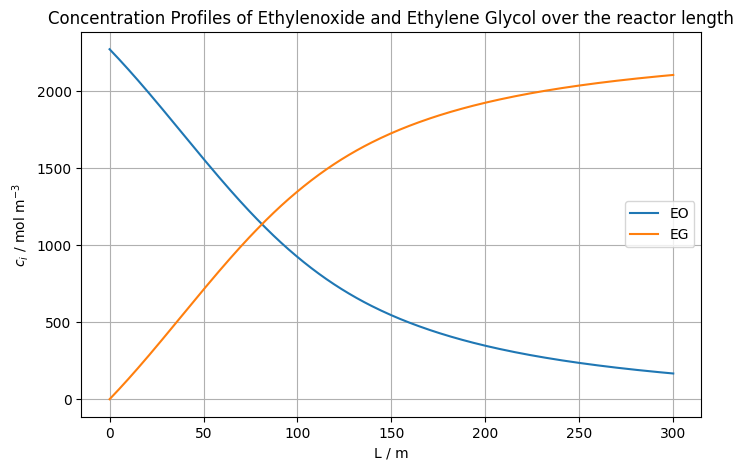

In [128]:
z = sol.t
cEO = sol.y[0]
cEG = sol.y[1]
T = sol.y[2]
X = (cEO0 - cEO) / cEO0

plt.figure(figsize=(8,5))
plt.plot(z, cEO, label='EO')
plt.plot(z, cEG, label='EG')
plt.xlabel('L / m')
plt.ylabel('$c_i$ / mol m$^{-3}$')
plt.title('Concentration Profiles of Ethylenoxide and Ethylene Glycol over the reactor length')
plt.legend()
plt.grid()
plt.show()

The inital concentration of ethylene oxide decreases exponentially with the reactor length due to the reaction. The concentration of ethylene glycol rises exponentially. The exponential trend is characteristic for a first order reaction. 

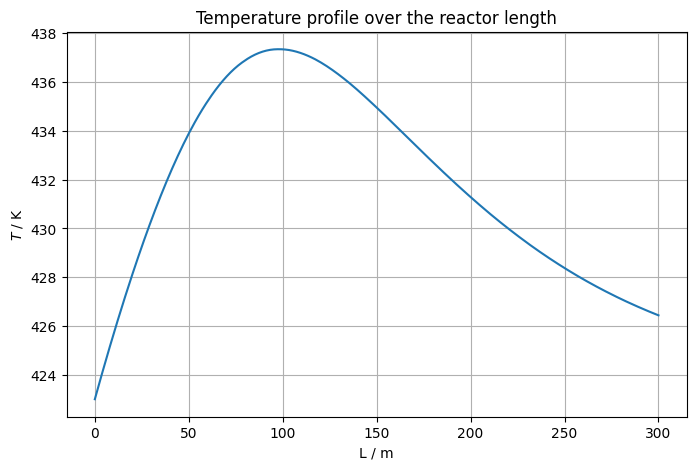

In [129]:
plt.figure(figsize=(8,5))
plt.plot(z, T)
plt.xlabel('L / m')
plt.ylabel('$T$ / K')
plt.title('Temperature profile over the reactor length')
plt.grid()
plt.show()

The temperature in the reactor is at first increasing since the heat generated is bigger than the transferred heat to the wall. After around 100 m it reaches a maximum of around 437 K. Here the generated heat is as high as the transferred heat. After that, the temperature in the reactor decreases. This is because of the lower EO concentration with the reactor length. This results in a decreasing reaction rate and decreasing generated heat. The transferred heat through the wall exceeds this.

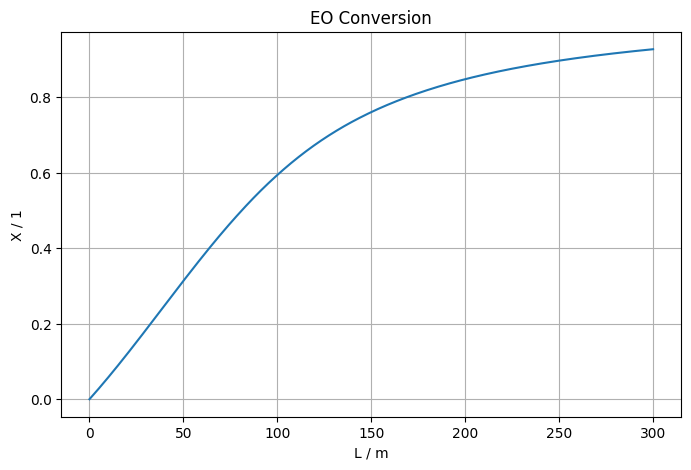

In [130]:
plt.figure(figsize=(8,5))
plt.plot(z, X)
plt.xlabel('L / m')
plt.ylabel('X / 1')
plt.title('EO Conversion')
plt.grid()
plt.show()

The conversion of ethylene oxide rises with the reactor length, since more of the reaction mixture is converted and no further reactions are assumed.

In the following a heat map is generated, where the influcence of the reactor length and the wall temperature on the conversion is investigated.

In [131]:
# Heatmap: EO conversion as a function of reactor length and wall temperature 

# Save original values
L_base = L
Twall_base = Twall

# Range of variables
L_values = np.linspace(50, 600, 25)
Twall_values = np.linspace(380, 460, 25)

# Matrix for conversion
X_heat = np.zeros((len(Twall_values), len(L_values)))

for i, Twall_case in enumerate(Twall_values):

    Twall = Twall_case

    for j, L_case in enumerate(L_values):

        L = L_case

        # Evaluation points
        z_case = np.linspace(0, L_case, 300)

        # Initial conditions
        y0_case = [cEO0, cEG0, Tin]

        # Solve reactor
        sol_case = solve_ivp(
            PFTR,
            [0, L_case],
            y0_case,
            method='BDF',
            t_eval=z_case
        )

        # Final conversion
        X_case = (cEO0 - sol_case.y[0]) / cEO0

        X_heat[i, j] = X_case[-1]

# Restore original values
L = L_base
Twall = Twall_base

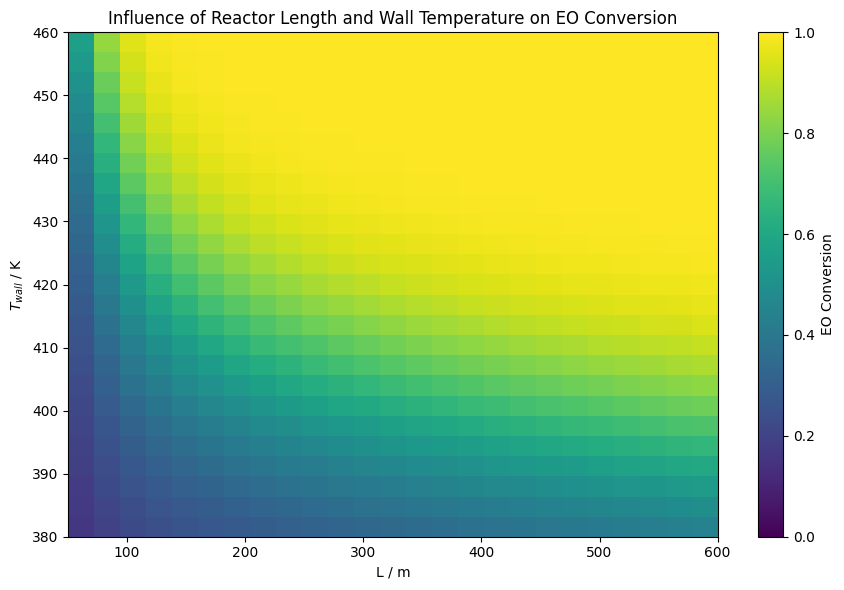

In [132]:
plt.figure(figsize=(9,6))

im = plt.imshow(
    X_heat,
    origin='lower',
    aspect='auto',
    extent=[
        L_values.min(),
        L_values.max(),
        Twall_values.min(),
        Twall_values.max()
    ],
    cmap='viridis',
    vmin=0,
    vmax=1
)

cbar = plt.colorbar(im)
cbar.set_label('EO Conversion')

plt.xlabel('L / m')
plt.ylabel(r'$T_{wall}$ / K')

plt.title('Influence of Reactor Length and Wall Temperature on EO Conversion')

plt.tight_layout()
plt.show()

## 3. Verification Checks

In the following the verification is checked. Since the stoichiometric coefficients of EO and EG are the same, the final concentration should be as high as the initial EO concentration. Furthermore the conversion should not exceed 1 and the final temperature should not be lower than the inlet- and wall temperature.

In [133]:
print(f'Final conversion = {X[-1]:.4f}')
print(f'Final temperature = {T[-1]:.2f} K')
print(f'EO outlet = {cEO[-1]:.2f} mol/m³')
print(f'EG outlet = {cEG[-1]:.2f} mol/m³')
print(f'Initial total concentration = {cEO[0] + cEG[0]:.2f} mol/m³')
print(f'Final total concentration = {(cEO[-1] + cEG[-1]):.2f} mol/m³')

Final conversion = 0.9265
Final temperature = 426.44 K
EO outlet = 166.91 mol/m³
EG outlet = 2103.09 mol/m³
Initial total concentration = 2270.00 mol/m³
Final total concentration = 2270.00 mol/m³


## 4. Sensitivity Analysis

In the following a sensitivity analysis is done. Therefore parameters like the inlet temperature, fluid velocity and the reactor length are variied.

In [134]:
def reset_base_case():

    global Tin, u, L, dR, hwall
    global A_cross, A_wall_per_length
    global zeval, y0

    Tin = 423
    u = 1.0
    L = 300
    dR = 0.03
    hwall = 0.5e3

    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    zeval = np.linspace(0, L, 300)

    y0 = np.array([cEO0, cEG0, Tin])

### 4.1. Inlet Temperature

At first the inlet temperature is variied and the effect of different inlet temperatures is studied.

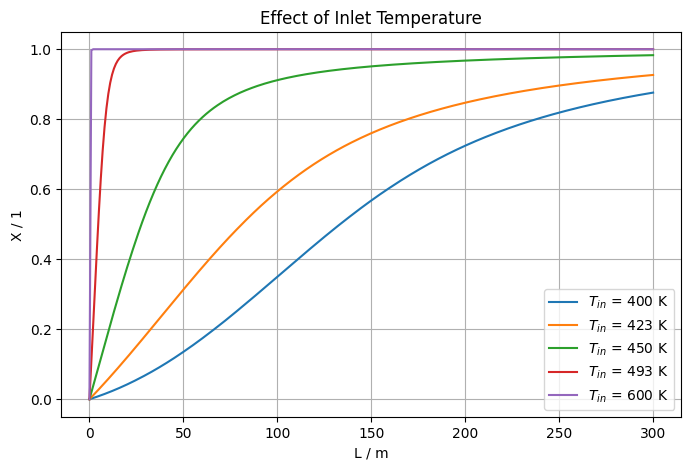

In [135]:
# Reset base case

reset_base_case()

Tin_list = [400, 423, 450, 493, 600]

plt.figure(figsize=(8,5))

for Tin_case in Tin_list:
    y0 = [cEO0, cEG0, Tin_case]
    sol_case = solve_ivp(PFTR,[0,L],y0,method='BDF',t_eval=zeval)
    X_case = (cEO0 - sol_case.y[0]) / cEO0
    plt.plot(sol_case.t, X_case, label=f'$T_{{in}}$ = {Tin_case} K')

plt.xlabel('L / m')
plt.ylabel('X / 1')
plt.title('Effect of Inlet Temperature')
plt.legend()
plt.grid()
plt.show()

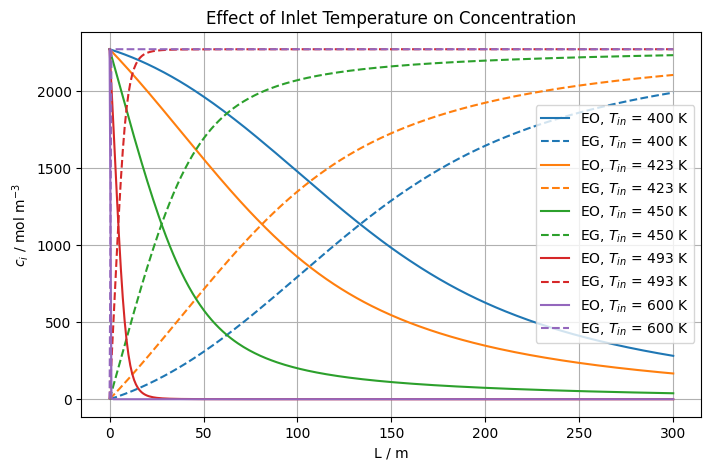

In [136]:
plt.figure(figsize=(8,5))

for Tin_case in Tin_list:

    y0 = [cEO0, cEG0, Tin_case]

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    # EO: solid line
    line, = plt.plot(
        sol_case.t,
        sol_case.y[0],
        '-',
        label=f'EO, $T_{{in}}$ = {Tin_case} K'
    )

    # EG: dashed line with same color as EO
    plt.plot(
        sol_case.t,
        sol_case.y[1],
        '--',
        color=line.get_color(),
        label=f'EG, $T_{{in}}$ = {Tin_case} K'
    )

plt.xlabel('L / m')
plt.ylabel(r'$c_i$ / mol m$^{-3}$')
plt.title('Effect of Inlet Temperature on Concentration')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Validation

summary = []

for Tin_case in Tin_list:

    y0 = [cEO0, cEG0, Tin_case]

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    summary.append({
        "Tin (K)": Tin_case,
        "EO outlet (mol/m³)": sol_case.y[0,-1],
        "EG outlet (mol/m³)": sol_case.y[1,-1],
        "Outlet Temperature (K)": sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df = pd.DataFrame(summary)
display(df.round(2))

,Tin (K),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,400,281.36,1988.64,428.29,87.61
1,423,166.91,2103.09,426.44,92.65
2,450,38.64,2231.36,424.47,98.30
3,493,0.02,2269.98,424.06,100.00
4,600,-0.00,2270.00,424.76,100.00


The conversion is for each case increasing as already discussed. For higher temperatures the conversion is higher because of the higher reaction rate due to the Arrhenius Law. For higher temperatures, the conversion reaches a value of almost 1 already at a lower reaction length. Thus it could be senseful to increase the temperature. This correlates indeed with higher operation costs (OPEX), but also leads to lower capital costs (CAPEX) when developing a new reactor.

### 4.2. Fluid Velocity

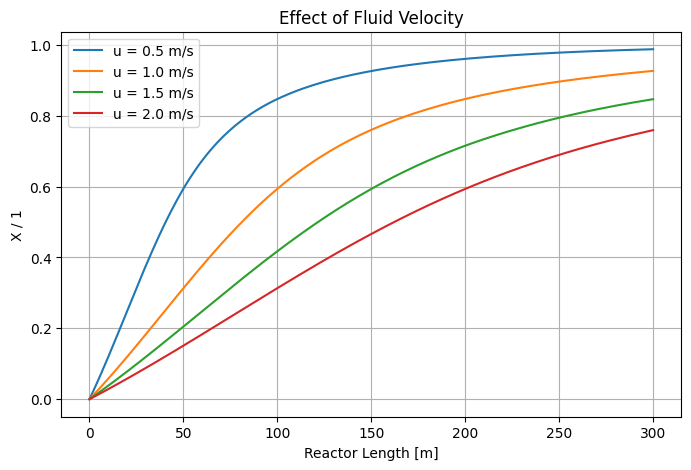

In [ ]:
# Reset base case

reset_base_case()

zeval = np.linspace(0, L, 300)

u_list = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'u = {u_case} m/s'
    )

plt.xlabel('Reactor Length [m]')
plt.ylabel('X / 1')
plt.title('Effect of Fluid Velocity')
plt.legend()
plt.grid()
plt.show()

u = 1.0

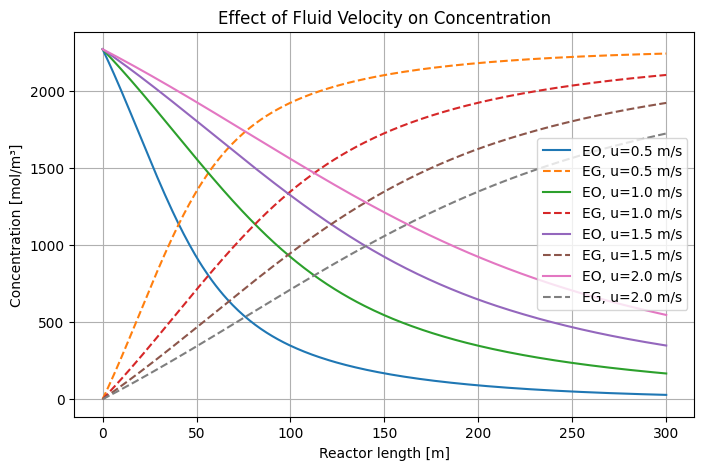

In [ ]:
# EO and EG Concentration Profiles

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t, sol_case.y[0],
             label=f'EO, u={u_case} m/s')

    plt.plot(sol_case.t, sol_case.y[1],
             '--',
             label=f'EG, u={u_case} m/s')

plt.xlabel('Reactor length [m]')
plt.ylabel('Concentration [mol/m³]')
plt.title('Effect of Fluid Velocity on Concentration')
plt.grid(True)
plt.legend()
plt.show()

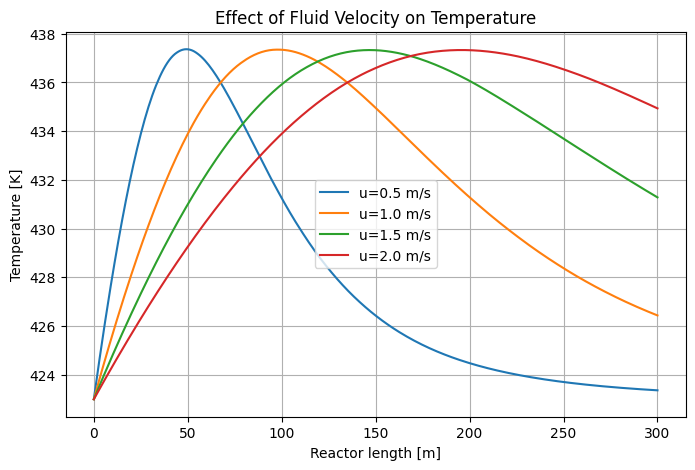

In [ ]:
# Effect of Fluid Velocity on Temperature

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[2],
             label=f'u={u_case} m/s')

plt.xlabel('Reactor length [m]')
plt.ylabel('Temperature [K]')
plt.title('Effect of Fluid Velocity on Temperature')
plt.grid(True)
plt.legend()
plt.show()

u = 1.0

In [ ]:
# Validation 

summary = []

for u_case in u_list:

    u = u_case

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0-sol_case.y[0])/cEO0

    summary.append({
        "Velocity (m/s)":u_case,
        "EO outlet (mol/m³)":sol_case.y[0,-1],
        "EG outlet (mol/m³)":sol_case.y[1,-1],
        "Outlet Temperature (K)":sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df=pd.DataFrame(summary)
display(df.round(2))

,Velocity (m/s),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,0.5,28.14,2241.86,423.37,98.76
1,1.0,166.91,2103.09,426.44,92.65
2,1.5,348.25,1921.75,431.28,84.66
3,2.0,546.52,1723.48,434.94,75.92


The conversion increases with a lower fluid  velocity. This is due to the higher residence time. Thus more EO can be converted to EG.

### 4.3. Reactor Length

In [ ]:
# Reset base case

reset_base_case()

L_list = [100, 200, 300, 400, 500, 700, 1000, 1500, 2000]

summary = []

for L_case in L_list:

    zeval_case = np.linspace(0, L_case, 300)

    sol_case = solve_ivp(
        PFTR,
        [0, L_case],
        y0,
        method='BDF',
        t_eval=zeval_case
    )

    X_case = (cEO0 - sol_case.y[0,-1]) / cEO0

    summary.append({
        "Reactor Length (m)": L_case,
        "EO outlet (mol/m³)": sol_case.y[0,-1],
        "EG outlet (mol/m³)": sol_case.y[1,-1],
        "Outlet Temperature (K)": sol_case.y[2,-1],
        "Conversion (%)": 100*X_case
    })

df = pd.DataFrame(summary)

display(df.round(3))

,Reactor Length (m),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,100,922.768,1347.232,437.338,59.349
1,200,346.944,1923.056,431.283,84.716
2,300,166.906,2103.094,426.439,92.647
3,400,89.405,2180.595,424.477,96.061
4,500,49.741,2220.259,423.704,97.809
5,700,15.964,2254.036,423.199,99.297
6,1000,2.974,2267.026,423.036,99.869
7,1500,0.181,2269.819,423.002,99.992
8,2000,0.011,2269.989,423.000,100.000


### 4.4. Heat Transfer Coeficient

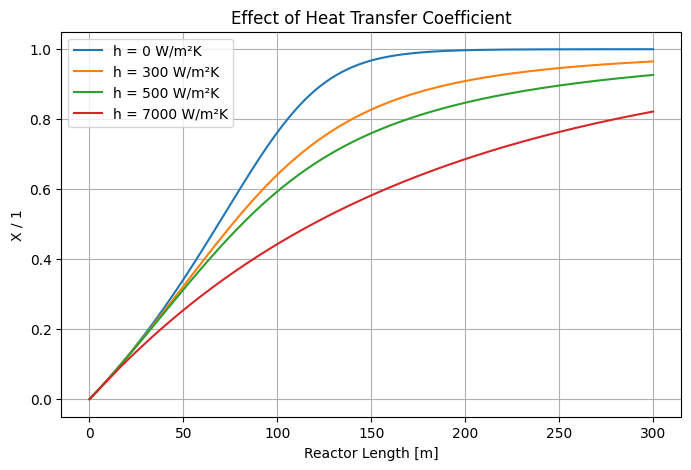

In [ ]:
# Reset base case

reset_base_case()

hwall_list = [0, 300, 500, 7000]

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'h = {h_case} W/m²K'
    )

plt.xlabel('Reactor Length [m]')
plt.ylabel('X / 1')
plt.title('Effect of Heat Transfer Coefficient')
plt.legend()
plt.grid()
plt.show()

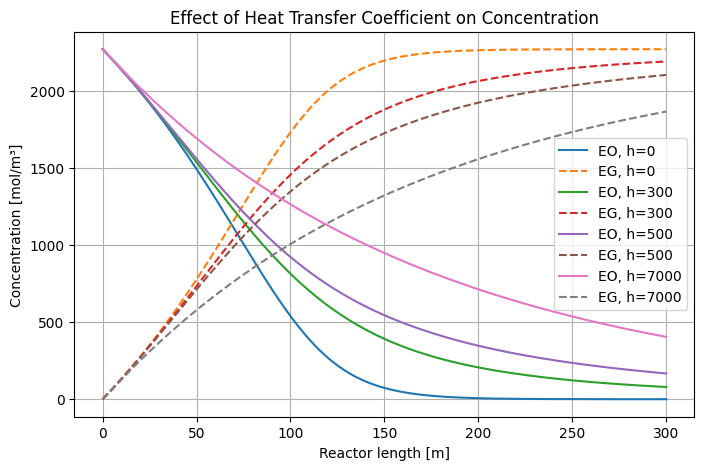

In [ ]:
# EO and EG Concentration Profiles

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[0],
             label=f'EO, h={h_case}')

    plt.plot(sol_case.t,
             sol_case.y[1],
             '--',
             label=f'EG, h={h_case}')

plt.xlabel('Reactor length [m]')
plt.ylabel('Concentration [mol/m³]')
plt.title('Effect of Heat Transfer Coefficient on Concentration')
plt.grid(True)
plt.legend()
plt.show()

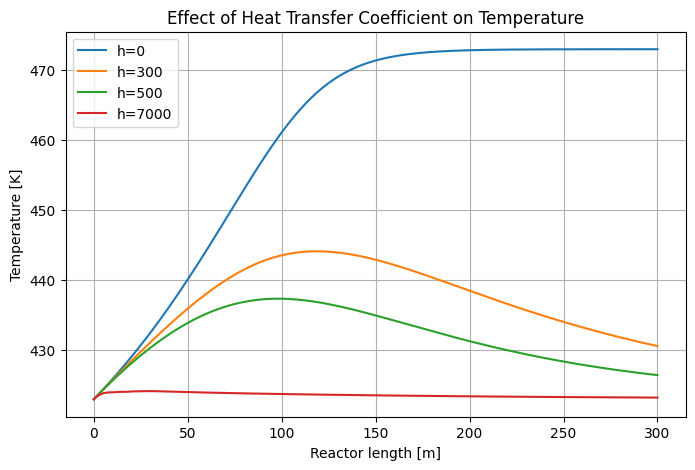

In [ ]:
# Effect of Heat Transfer Coefficient on Temperature

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[2],
             label=f'h={h_case}')

plt.xlabel('Reactor length [m]')
plt.ylabel('Temperature [K]')
plt.title('Effect of Heat Transfer Coefficient on Temperature')
plt.grid(True)
plt.legend()
plt.show()

hwall = 0.5e3

In [ ]:
# Validation 

summary=[]

for h_case in hwall_list:

    hwall=h_case

    sol_case=solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case=(cEO0-sol_case.y[0])/cEO0

    summary.append({
        "h (W/m²K)":h_case,
        "EO outlet (mol/m³)":sol_case.y[0,-1],
        "EG outlet (mol/m³)":sol_case.y[1,-1],
        "Outlet Temperature (K)":sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df=pd.DataFrame(summary)
display(df.round(2))

,h (W/m²K),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,0,0.05,2269.95,472.95,100.00
1,300,79.28,2190.72,430.58,96.51
2,500,166.91,2103.09,426.44,92.65
3,7000,404.29,1865.71,423.23,82.19


With a lower heat transfer coefficient, the conversion is higher because the heat transfer with the wall is worse and thus the temperature in the reactor is higher. The reaction rate is then higher. 

### 4.5 Reactor diameter

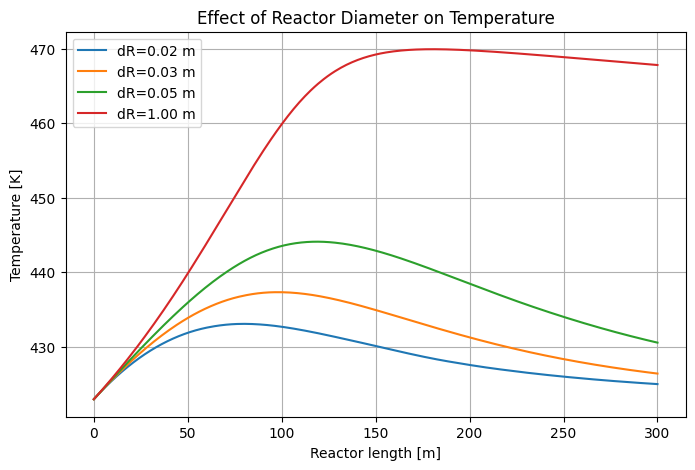

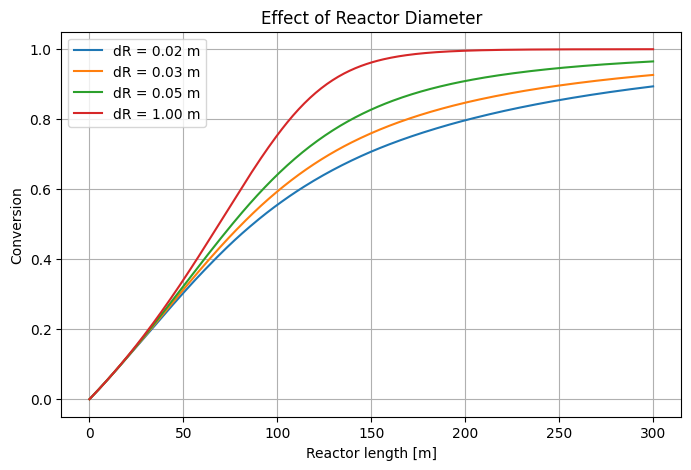

In [ ]:
# Reset base case

reset_base_case()

dR_list = [0.02, 0.03, 0.05, 1]  # m

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i
    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    sol = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=z
    )

    plt.plot(z, sol.y[2], label=f"dR={dR_i:.2f} m")

plt.xlabel("Reactor length [m]")
plt.ylabel("Temperature [K]")
plt.title("Effect of Reactor Diameter on Temperature")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i

    #Geometric relations
    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR
    
    sol = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_temp = (cEO0 - sol.y[0]) / cEO0

    plt.plot(zeval, X_temp, label=f"dR = {dR_i:.2f} m")

plt.xlabel("Reactor length [m]")
plt.ylabel("Conversion")
plt.title("Effect of Reactor Diameter")
plt.legend()
plt.grid()
plt.show()

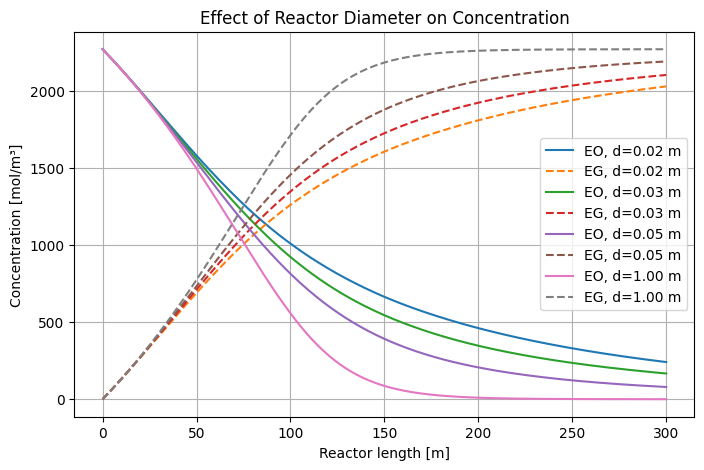

In [ ]:
# EO and EG Concentration Profiles

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i

    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    sol_case = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    plt.plot(sol_case.t,
             sol_case.y[0],
             label=f'EO, d={dR_i:.2f} m')

    plt.plot(sol_case.t,
             sol_case.y[1],
             '--',
             label=f'EG, d={dR_i:.2f} m')

plt.xlabel('Reactor length [m]')
plt.ylabel('Concentration [mol/m³]')
plt.title('Effect of Reactor Diameter on Concentration')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Validation

summary=[]

for dR_case in dR_list:

    dR=dR_case

    A_cross=np.pi*dR**2/4
    A_wall_per_length=np.pi*dR

    sol_case=solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case=(cEO0-sol_case.y[0])/cEO0

    summary.append({
        "Diameter (m)":dR_case,
        "EO outlet (mol/m³)":sol_case.y[0,-1],
        "EG outlet (mol/m³)":sol_case.y[1,-1],
        "Outlet Temperature (K)":sol_case.y[2,-1],
        "Conversion (%)":100*X_case[-1]
    })

df=pd.DataFrame(summary)
display(df.round(2))

,Diameter (m),EO outlet (mol/m³),EG outlet (mol/m³),Outlet Temperature (K),Conversion (%)
0,0.02,240.93,2029.07,425.03,89.39
1,0.03,166.91,2103.09,426.44,92.65
2,0.05,79.28,2190.72,430.58,96.51
3,1.00,0.15,2269.85,467.79,99.99


To check Fran 
"Increasing the reactor diameter leads to higher EO conversion and higher EG production. This behavior is mainly explained by the lower surface-to-volume ratio of the reactor. As the diameter increases, heat exchange with the reactor wall becomes less effective, allowing the reaction mixture to reach higher temperatures. Since the hydration of ethylene oxide is strongly temperature-dependent, the higher reactor temperature increases the reaction rate and therefore the final conversion." 
** D= 1 m can be discussed as a extreme case"

A higher reactor diameter results in a higher conversion because the heat transfer with the wall is worse. This results in higher temperatures in the reactor and thus higher reaction rates.

## 5. Summary Table

In [ ]:
print("Case Summary")
print("--------------------------")
print(f"Final Conversion = {X[-1]:.4f}")
print(f"Final Temperature = {T[-1]:.2f} K")
print(f"EO Outlet Concentration = {cEO[-1]:.2f} mol/m³")
print(f"EG Outlet Concentration = {cEG[-1]:.2f} mol/m³")

Case Summary
--------------------------
Final Conversion = 0.9265
Final Temperature = 426.44 K
EO Outlet Concentration = 166.91 mol/m³
EG Outlet Concentration = 2103.09 mol/m³


In [ ]:
print("Software Versions")
print("-----------------")
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pd.__version__}")

Software Versions
-----------------
Python      : 3.12.3
NumPy       : 1.26.4
Matplotlib  : 3.10.3
Pandas      : 2.2.2
